<a href="https://colab.research.google.com/github/tompickering-aur/Practice/blob/main/notebooks/05_Airline_TextAnalytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Airline Text Analytics

Airline companies are in fierce competition. One key dimension of competition is customer service, a direct driver of customer satisfaction.

![Alliances](https://raw.githubusercontent.com/ciri/iese-dsfb-mim/main/resources/text/airline-alliances.png)

As part of an effort to better understand passenger satisfaction within the Star Alliance network, we analyze customer reviews from thousands of airline passengers. The goal is to identify how factors like sentiment, seat type, travel purpose, and specific routes relate to overall recommendation rates.

The dataset includes 23,000+ reviews, with key variables such as:

- `Airline Name`: the name of the airline.
- `Route`: the flight route taken by the passenger.
- `Review`: free-text review written by the traveler.
- `Type Of Traveller`: e.g., Solo Leisure, Business, Couple.
- `Recommended`: whether the traveler recommends the airline (yes/no).
- `Seat Type`: seat class (e.g., Economy, Business).

Data Source: [Airlinequality.com](https://www.airlinequality.com/) via [Kaggle](https://www.kaggle.com/datasets/khushipitroda/airline-reviews/data)

**Required packages** — run once before starting:

```bash
!pip install nltk tqdm transformers torch
```

In [ ]:
# run once and then comment out!
# !pip install nltk tqdm transformers torch

## Part I: Working with Text Data

### Strings

Text data always starts out in the form of a string. A **string** is a sequence (list) of **characters**. This includes the (English) alphanumeric characters and also special characters like white space, punctuation, etc. Other symbols, like emoticons, can also appear in your data, specially in social networks data. Besides that, you can also find letters from other languages (Spanish, Portuguese, etc) or alphabets (Cyrillic, hiragana, etc), and even ideographs (such as Han characters).


### Characters as numbers

There is a basic set of 127 characters, called the **ASCII characters**, which are encoded in the same way by all the computers, so you will never have trouble with them. They include the English letters (without accents), the numbers, basic punctuation (not curly quote marks or long dashes), white space, **control characters** such as the new line, represented in programming languages as `\n`, and other symbols familiar to you, such as the dollar ($) and the hash (#) symbols. The complete list can be easily found in Internet.

Non-ASCII characters can be encoded by different computers or different text editors in different ways. Mind that, if you capture string data on your own, you will probably find some of these characters in your data. Even when the documents are expected to be in English, they can be contaminated by other languages: Han
characters, German dieresis, Spanish eñe, etc.

The preferred **encoding** is **UTF-8 (utf-8)**, which is the default encoding in Macintosh computers. Reading and writing text files in Pandas, the argument encoding allows you to manage both UTF-8 and the alternative encoding **Latin-1 (latin1)**. Windows computers use their own system, which is region specific. In US and Western Europe, this is **Windows-1252**, which is very close to Latin-1, though not exactly the same.

In [ ]:
'A' == 'a'
#65 == 97

False

In [ ]:
# you can split and join strings together
iese = "IESE Business School"

splitted = iese.split(' ')

splitted

'-----'.join(splitted)

'IESE-----Business-----School'

### Strings as lists

Both lists and strings are **sequences**, so they share some core behaviours. A string can be thought of as a list of characters. You can use `len()` and slicing just like a list:

In [ ]:
school = 'IESE Business School'
print(len(school))
print(school[:4])    # first 4 characters
print(school[-6:])   # last 6 characters

20
IESE
School



### Python string methods

Python has a rich set of methods for manipulating strings:

| Method | What it does |
|---|---|
| `lower()` / `upper()` | Change case |
| `replace(old, new)` | Find and replace |
| `split(sep)` | Split into a list of parts |
| `join(list)` | Join a list back into a string |
| `count(pattern)` | Count occurrences |

In [ ]:
name = 'Tamara van der Does'

print(name.upper())
print(name.lower())
print(name.split(' '))
print('---'.join(name.split(' ')))

TAMARA VAN DER DOES
tamara van der does
['Tamara', 'van', 'der', 'Does']
Tamara---van---der---Does


## Airline Reviews Dataset

Let's load the data. I've already partially cleaned it up for you (no duplicates). You can download it from [here](https://raw.githubusercontent.com/tamaravdd/iese-dsmba/3b28bd87a7f120e865dc83edb6404ca9da5ba5b7/resources/text/Airline_Reviews_v2.csv).

> 🧠 **Pause and Think:** We're about to load 23,000+ airline reviews. Before you run the cell — what do you expect the split between seat types to be? And which airline do you predict has the worst average rating in this dataset?

In [ ]:
import pandas as pd

pd.set_option('display.max_colwidth', None)

## if using anaconda
# df = pd.read_csv('data_raw/Airline_Reviews_v2.csv')[['Airline Name','From','To','Via','Review','Type Of Traveller','Recommended','Seat Type']]

## if using colab
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data_raw/Airline_Reviews_v2.csv")[['Airline Name','From','To','Via','Review','Type Of Traveller','Recommended','Seat Type']]


## Or download every time:
#df = pd.read_csv('https://raw.githubusercontent.com/tamaravdd/iese-dsmba/3b28bd87a7f120e865dc83edb6404ca9da5ba5b7/resources/text/Airline_Reviews_v2.csv')[['Airline Name','From','To','Via','Review','Type Of Traveller','Recommended','Seat Type']]

df.head(5)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Airline Name,From,To,Via,Review,Type Of Traveller,Recommended,Seat Type
0,AB Aviation,Moroni,Moheli,NaN,"Moroni to Moheli. Turned out to be a pretty decent airline. Online booking worked well, checkin and boarding was fine and the plane looked well maintained. Its a very short flight - just 20 minutes or so so i didn't expect much but they still managed to hand our a bottle of water and some biscuits which i though was very nice. Both flights on time.",Solo Leisure,1,Economy Class
1,AB Aviation,Moroni,Anjouan,NaN,"Moroni to Anjouan. It is a very small airline. My ticket advised me to turn up at 0800hrs which I did. There was confusion at this small airport. I was then directed to the office of AB Aviation which was still closed. It opened at 0900hrs and I was told that the flight had been put back to 1300hrs and that they had tried to contact me. This could not be true as they did not have my phone number. I was with a local guide and he had not been informed either. I presume that I was bumped off. The later flight did operate but as usual, there was confusion at check-in. The flight was only 30mins and there were no further problems. Not a good airline but it is the only one for Comoros.",Solo Leisure,0,Economy Class
2,AB Aviation,Anjouan,Dzaoudzi,NaN,"Anjouan to Dzaoudzi. A very small airline and the only airline based in Comoros. Check-in was disorganised because of locals with big packages and disinterested staff. The flight was fortunately short (30 mins). Took off on time and landed on time. With a short flight like there was of course no in-flight entertainment nor cabin service except for biscuits and a bottle of water, which was quite nice!",Solo Leisure,0,Economy Class
3,Adria Airways,Frankfurt,Pristina,NaN,"Please do a favor yourself and do not fly with Adria. On the route from Munich to Pristina in July 2019 they lost my luggage and for 10 days in a row, despite numerous phone calls they were not able to locate it. 11 days later the luggage arrived at the destination completely ruined. Applying for compensation, they ignored my request. Foolishly again, I booked another flight with them (345 euros) Frankfurt - Pristina in September 2019. They cancelled the flight with no reason 24 hours before the departure. Desperate phone calls to customer service to get anything (rerouting, compensation, etc) were not responded. I will never fly again with Adria. What a disgrace! Shame on you Adria for constantly deceiving your customers.",Solo Leisure,0,Economy Class
4,Adria Airways,Sofia,Amsterdam,Ljubljana,"Do not book a flight with this airline! My friend and I should have returned from Sofia to Amsterdam on September 22 and 3 days before, they sent us an SMS informing the flight was cancelled. For 3 straight days we tried to reach the airline and the web agent (e-dreams) and we did not get a solution. Finally, 18 hours before our cancelled flight time, and after 35 minutes on a call (waiting), the airline was able to get us on a flight with Lufthansa. Do not book Adria Airways, it is unreliable and in our case, it ruined our last days of holidays since we needed to be on the phones all day.",Couple Leisure,0,Economy Class


### Exploring the dataset

In [ ]:
# look a bit at the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23046 entries, 0 to 23045
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Airline Name       23046 non-null  object
 1   From               19332 non-null  object
 2   To                 19312 non-null  object
 3   Via                4218 non-null   object
 4   Review             23046 non-null  object
 5   Type Of Traveller  19421 non-null  object
 6   Recommended        23046 non-null  int64 
 7   Seat Type          22058 non-null  object
dtypes: int64(1), object(7)
memory usage: 1.4+ MB


> ✅ **Sanity check:** You should have **23,046 rows** and 8 columns. Check `df.isna().sum()` — some columns like `Via` have many nulls (not all flights have a transit stop), which is fine. `Review`, which is our most important variable, seems fine.

There is not much to `describe()` here since most columns are text. Let's use `.value_counts()` to count categories, and `.groupby()` to aggregate.

In [ ]:
df['Seat Type'].value_counts()

,count
Seat Type,
Economy Class,19129
Business Class,2097
Premium Economy,646
First Class,186


In [ ]:
df.groupby('Seat Type').count()

,Airline Name,From,To,Via,Review,Type Of Traveller,Recommended
Seat Type,,,,,,,
Business Class,2097,1806,1805,517,2097,1808,2097
Economy Class,19129,16747,16731,3533,19129,16829,19129
First Class,186,168,168,23,186,168,186
Premium Economy,646,608,605,145,646,613,646


In [ ]:
df.groupby('Seat Type').nunique()

,Airline Name,From,To,Via,Review,Type Of Traveller,Recommended
Seat Type,,,,,,,
Business Class,217,436,471,175,2097,4,2
Economy Class,489,2025,2271,677,19129,4,2
First Class,75,103,106,19,186,4,2
Premium Economy,157,240,260,83,646,4,2


>✏️ **You try it**
>
> What's the most common route?
>
> Hint: use From and To, you can combine them using `df.From` + `df.To`.
>
> Extension: What plot could you make to represent the route intensity?

<details>
<summary>Click to reveal solution</summary>

```python
df['Via'].value_counts()
df['Route'] = df.From +  df.To
df.Route.value_counts()


# import libraries
import matplotlib.pyplot as plt
import seaborn as sns


# scatterplot
routes = (
    df.dropna(subset=['From','To'])
      .groupby(['From','To'])
      .size()
      .reset_index(name='count')
)
top_from = routes['From'].value_counts().head(20).index
top_to   = routes['To'].value_counts().head(20).index

sub = routes[
    routes['From'].isin(top_from) &
    routes['To'].isin(top_to)
]
matrix = sub.pivot(index='From', columns='To', values='count').fillna(0)

plt.figure(figsize=(10,8))
sns.heatmap(matrix, cmap='Blues', vmin=0.0001)
plt.title('Route Intensity Heatmap')
plt.xlabel('To')
plt.ylabel('From')
plt.tight_layout()
plt.show()

#other option
top_via = df['Via'].value_counts().head(10)

plt.figure(figsize=(6,4))
sns.barplot(x=top_via.values, y=top_via.index)
plt.title('Most Common Via Stops')
plt.xlabel('Count')
plt.ylabel('Via')
plt.tight_layout()
plt.show()
```
</details>

### Exploring the review text

When a Pandas column contains strings, we use `.str` to apply **string methods** to every row of the column. Pandas string methods are vectorized versions of the above methods. They return a series of the same length, in which each term results from applying a string function to the corresponding row.

The syntax of these functions is typically `s.str.fname(args)`, where `s` is a Pandas series of strings (or a list of strings) and `.fname` is a method we want to apply to each row.

For example, `.str.contains("pattern")` returns a whole column of Boolean values (True wherever the pattern appears and Falese where it doesn't):

> 🧠 **Pause and Think:** If you were a Star Alliance manager, what's the first keyword you'd search for in 23,000 reviews? Think of a word that would distinguish satisfied from dissatisfied passengers. Then try it below.

In [ ]:
f_has_space = df.Review.str.lower().str.contains("space")
df[f_has_space].head(3)

,Airline Name,From,To,Via,Review,Type Of Traveller,Recommended,Seat Type
41,Adria Airways,Manchester,Ljubljana,NaN,"Excellent flights both ways with Adria Airways from Manchester to Ljubljana. Staff friendly but unobtrusive. Leg room far better than most economy flights, seats comfy and plenty of storage space. Flights on time, quick and efficient boarding and disembarking, smooth take offs and landings. All in all a very pleasant experience.",Family Leisure,1,Economy Class
100,Aegean Airlines,Athens,Chania,NaN,"We took 3 flights with Aegean and would not recommend them to anyone. Had 3 issues: 1. They overbooked our flight and bumped many people. We bought our flight 3 months ahead, but checked in about 18 hours before our flight (they allow check-in up to 24 hours ahead). We were issued a “standby” ticket without any seats. When we got to the gate, we were told we may or may not get onto the flight and if we didn’t then we would have to wait 4 hours for the late night flight, or try again in the morning. Lots of other people in the same situation. We were never issued boarding passes but we kept following up with the person at the ticket counter until they gave us passes, it seems like due to our persistence and nothing systematic. Luckily we got on that flight, but others didn’t. Nowhere in the policy does it say that whether or not you get on the flight is related to your check-in time. If you take Aegean, check in right away and be persistent about asking for seats! 2. They apply a checked bag policy at will. We were sitting near the gate. The gate attendants approached us and asked to weigh our bags. Our bags, which fit easily into any overhead bin (including previous Aegean flights) were found to be slightly overweight (apparently 9kgs are allowed, ours were about 10kgs). We asked if we could move 1kg into our purse / backpack. They said no, they need to check the two bags, and by the way they are charging us 40Euro per bag. This was for a 45 min flight from an island to Athens. We had no choice and were forced to pay. Also, there was no consistency in the way this rule was applied. We saw plenty of other people with carry-ons larger than ours allowed on the plane and there was plenty of space in the overhead bins. 3. Every flight we were on was late. Two of three were late by over 45 mins. We didn’t have any connections, but I imagine many connecting flights were missed. And, this didn’t happen to us, but it’s worth noting that when we landed in Athens, there were about 30 people waiting at the lost baggage desk. Most of them looked very angry. I asked one person what happened, and apparently an entire flight did not have their bags transferred at a connection. So not only will they force you to check your carry-on and then pay for a checked bag, they might lose it too. All-in-all, this is a pretty bad track record for 3 short island hop flights.",Couple Leisure,0,Economy Class
111,Aegean Airlines,Mytilini,Athens,NaN,"Check-in uneventful. Boarding a zoo with a rude employee denying me boarding, claiming some zone story. Upon boarding I found a number of passengers that were probably the right 'zone' since they were seated in the rear already. An old ATR POS that Aegean must likely keep to connect some small islands that cannot accommodate jets. Why they would use these consistently for the third largest Greek island is unclear to me. Once seated in 15C and having put my backpack above, I see the flight attendant pushing it to make space for someone's big suitcase. When I objected, she pulled it down and told me in the rudest way to put it under the seat in front of me. Said attendant did not wear a name tag.",Business,0,Economy Class


In [ ]:
# Let's read one full review
print(df.loc[41].Review)

# or
# df.loc[41]['Review']

Excellent flights both ways with Adria Airways from Manchester to Ljubljana. Staff friendly but unobtrusive. Leg room far better than most economy flights, seats comfy and plenty of storage space. Flights on time, quick and efficient boarding and disembarking, smooth take offs and landings. All in all a very pleasant experience.


>✏️ **You try it**
>
> 1. Use `str.contains` to find the number of reviews which mention the following keywords: `'Crew'`, `'Bag'`, `'Passenger'`.
> 2. Calculate the total count across all 3 keywords.
> 3. Does review 186 from Aegean Airlines contain the word crew?
>
> Hint: don't forget `.lower()`!

<details>
<summary>Click to reveal solution</summary>

```
f_crew      = df.Review.str.lower().str.contains('crew')
f_bag       = df.Review.str.lower().str.contains('bag')
f_passenger = df.Review.str.lower().str.contains('passenger')

(f_crew | f_bag | f_passenger).sum()

df.iloc[186].Review
```
</details>

### Exploring the most frequent words

Advanced techniques like topic modeling (LDA) or transformer-based classification exist, but a simple and quick method is **word frequency analysis**. It gives a fast sense of recurring topics — service, food, delays, seats — without any machine learning.

<Axes: >

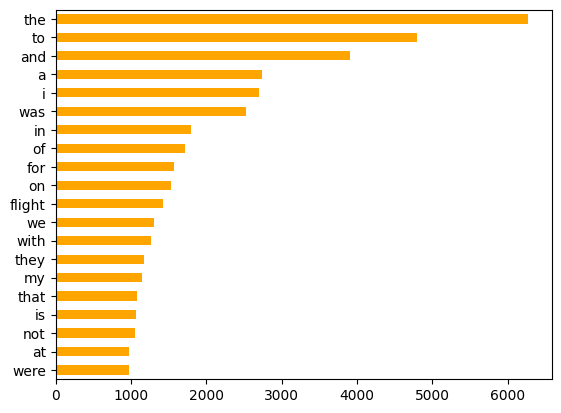

In [ ]:
# let's select a random sample of 1000 reviews (so it goes faster)
# random_state=42 makes it reproducible (same 1000 rows every time you run it)
sample = df.sample(1000, random_state=42)

# make them all lower case and split them
all_words = sample.Review.str.lower().str.split().sum()
# sum adds all the words together into one flat list
# [1, 2] + [3, 4]  # → [1, 2, 3, 4]


pd.Series(all_words).value_counts().head(20)[::-1].plot.barh(color='orange')
#pd.Series(all_words) — wraps the list in a Series so pandas can work with it
#.head(20) — keeps only the top 20
#.plot.barh(color='orange') — plots it as a horizontal bar chart

In [ ]:
all_words[:5]

['best', 'airline', 'for', 'transatlantic', 'travel']

> ✅ **Sanity check:** The top words should be common English stopwords — 'the', 'a', 'was', 'to', 'I'. If you see content words like 'flight' or 'seat' in the top 5, something went wrong with the sample or the split.

The top terms are mostly **stopwords** — words that carry no meaning (the, a, I, was ...). We can filter them out using a standard list from NLTK:

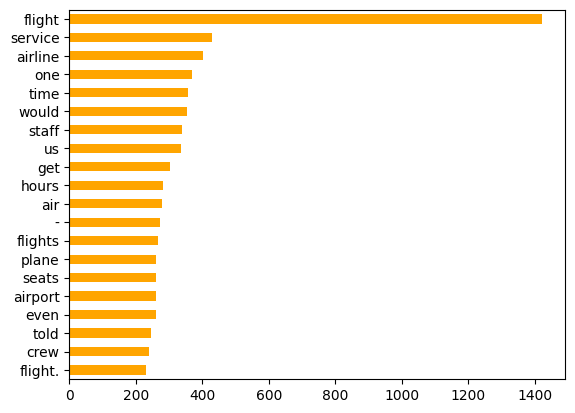

In [ ]:
#! pip install nltk
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# choose the stopwords we want to use
stop = set(stopwords.words('english'))

# filter words
filtered_words = [w for w in all_words if w not in stop]
pd.Series(filtered_words).value_counts().head(20)[::-1].plot.barh(color='orange');

Here we used a one-line loop! It is called a **list comprehension** and just a compact way of building a list.

Think of it as a sentence
```
filtered_words = [w for w in all_words if w not in stop]
```
"keep each word, for every word in the list, as long as it's not a stopword."

This is how it would look like written as a long loop:

In [ ]:
filtered_words = []
for w in all_words:
    if w not in stop:
        filtered_words.append(w)

# setup an empty list
# Go through every word in all_words
#and if it's not a stopword, append (add) it to the list

Let's try to plot this as a wordcloud. The beauty and power of python is that - regardless of your objective - you can always find some package that will get close to what you want:

<center>
    <img src='https://raw.githubusercontent.com/ciri/iese-dsfb/main/images/xkcdimport.png' width='50%'>
</center>

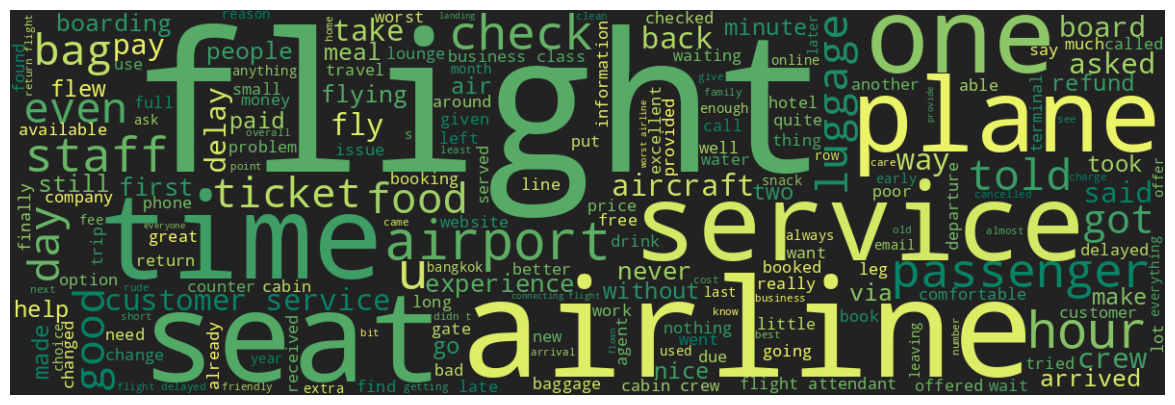

In [ ]:
#! pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join(filtered_words)
wordcloud = WordCloud(width=1200, height=400, background_color='#222222', colormap='summer').generate(text)

plt.figure(figsize=(15, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

> 🧠 **Pause and Think:** Look at the wordcloud. What topics do you see? What's surprisingly absent? Can a wordcloud alone tell you whether passengers are *happy* or *unhappy* about crew? What limitation does this reveal?

---
## Part II: Sentiment Analysis

Word frequency tells us **what** passengers write about. But it treats every word in isolation and can't distinguish *"good food"* from *"not good food"*, or *"no delays"* from *"constant delays"*. Is looking at individual words really enough?

Star Alliance carries ~762 million passengers per year across 25 member airlines. Yet in 23,046 verified reviews from Airlinequality.com:

| Segment | Do not recommend | Recommend |
|---|---|---|
| **Star Alliance** | **70%** | 30% |
| All airlines in dataset | 66% | 34% |

**Governing question:** Why do Star Alliance passengers not recommend their airline?

<svg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 820 300' font-family='Arial,sans-serif'>

  <!-- Connectors first so boxes sit on top -->
  <line x1='196' y1='150' x2='228' y2='150' stroke='#7F7F7F' stroke-width='1.5'/>
  <line x1='228' y1='50'  x2='228' y2='250' stroke='#7F7F7F' stroke-width='1.5'/>
  <line x1='228' y1='50'  x2='350' y2='50'  stroke='#7F7F7F' stroke-width='1.5'/>
  <line x1='228' y1='150' x2='350' y2='150' stroke='#7F7F7F' stroke-width='1.5'/>
  <line x1='228' y1='250' x2='350' y2='250' stroke='#7F7F7F' stroke-width='1.5'/>

  <!-- Root -->
  <rect x='8' y='110' width='188' height='80' rx='3' fill='#002060'/>
  <text x='102' y='138' text-anchor='middle' fill='white'   font-size='12' font-weight='bold'>Why do passengers</text>
  <text x='102' y='156' text-anchor='middle' fill='white'   font-size='12' font-weight='bold'>not recommend?</text>
  <text x='102' y='176' text-anchor='middle' fill='#7BAFD4' font-size='10'>Star Alliance: 70% don't recommend</text>

  <!-- Leaf 1: Hard product -->
  <rect x='350' y='18' width='190' height='64' rx='3' fill='#DAE3F3' stroke='#1F5C99' stroke-width='1'/>
  <text x='445' y='40' text-anchor='middle' fill='#002060' font-size='12' font-weight='bold'>Hard product</text>
  <text x='445' y='58' text-anchor='middle' fill='#1F5C99' font-size='10'>Cabin · Seat · IFE</text>
  <text x='554' y='50' text-anchor='start'  fill='#595959' font-size='10'>→ Measurable via structured ratings</text>

  <!-- Leaf 2: Soft product (highlighted) -->
  <rect x='350' y='118' width='190' height='64' rx='3' fill='#1F5C99' stroke='#002060' stroke-width='2'/>
  <text x='445' y='140' text-anchor='middle' fill='white'   font-size='12' font-weight='bold'>Soft product</text>
  <text x='445' y='158' text-anchor='middle' fill='#BDD4ED' font-size='10'>Crew · Food · Beverage</text>
  <text x='554' y='142' text-anchor='start'  fill='#595959' font-size='10'>→ Lives in free-text reviews</text>
  <text x='554' y='158' text-anchor='start'  fill='#595959' font-size='10'>★ Focus of this session</text>

  <!-- Leaf 3: Operations -->
  <rect x='350' y='218' width='190' height='64' rx='3' fill='#DAE3F3' stroke='#1F5C99' stroke-width='1'/>
  <text x='445' y='240' text-anchor='middle' fill='#002060' font-size='12' font-weight='bold'>Operational performance</text>
  <text x='445' y='258' text-anchor='middle' fill='#1F5C99' font-size='10'>Punctuality · Baggage · Reliability</text>
  <text x='554' y='250' text-anchor='start'  fill='#595959' font-size='10'>→ Measurable via OTP and delay records</text>

</svg>

For that we now turn to **sentiment analysis**: a natural language processing (NLP) technique used to identify and quantify emotions in text. It is a staple of marketing analytics, as it helps companies understand how customers feel about their brand, products, or services by analyzing reviews, social media, and survey responses.

Today, let us try to see if we can discover any positive or negative trends in the flight experience.

We'll go through three approaches, each more powerful (and discovered later):

| Approach | Method | Speed | Accuracy |
|---|---|---|---|
| 1. Ad-hoc | Keyword matching | Instant | Low |
| 2. Lexicon-based | VADER dictionary | Fast | Medium |
| 3. Machine Learning | Transformer model | Slower | High |

> 🧠 **Pause and Think:** Before we start — write down a review sentence where the word 'good' appears but the review is actually negative. And one where 'bad' appears but the overall message is positive. Keep these in mind as we test each approach.

### Approach 1: Ad-hoc (Keyword Matching)

The simplest method: check if positive or negative words appear in the review.

In [ ]:
good = df.Review.str.lower().str.contains('good')
bad  = df.Review.str.lower().str.contains('bad')

print(f"Reviews containing 'good': {good.mean():.1%}")
print(f"Reviews containing 'bad':  {bad.mean():.1%}")

Reviews containing 'good': 21.6%
Reviews containing 'bad':  9.8%


>✏️ **You try it**
>
> Implement the sentiment scoring function. Define the sentiment of review $i$ as:
> $$S_i = G_i - B_i$$
> where $G_i = 1$ if "good" appears, $B_i = 1$ if "bad" appears.
>
> Plot the distribution of sentiment scores as a histogram.

<details>
<summary>Click to reveal solution</summary>

```
df['simple_sentiment'] = df.Review.str.lower().str.contains('good').astype(int) \
                        - df.Review.str.lower().str.contains('bad').astype(int)
df['simple_sentiment'].hist(bins=5);
```
</details>

Here is an alternative way to write this using a function and applying it row by row.

In [ ]:
# first we define the function writing "review" as a placeholder
# for when we plug in the actual data
# we ask the function to do a few things to that review
# and return the difference between is_good and is_bad

def sentiment(review):
    is_good = 'good' in review.lower()
    is_bad  = 'bad'  in review.lower()
    return is_good - is_bad

# python will check the general syntax (parentheses, commas, etc.)


Key elements in a function:
1. You define the function and include names for the arguments you want to input.
2. You indent your code and write down a series of actions to be taken upon the arguments.
3. You specify what you want your function to return (still indented)

Then we use `.apply()`, which applies a function row-by-row. This pattern becomes essential for more complex scoring later:

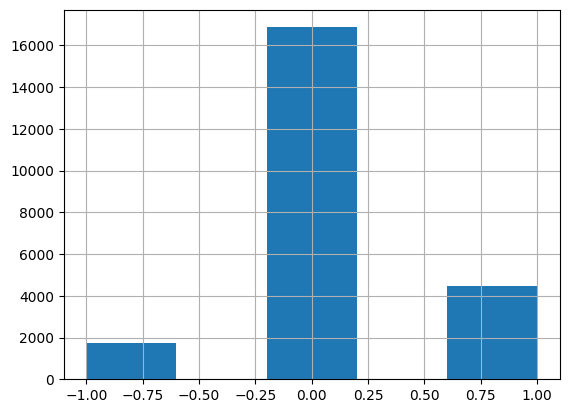

In [ ]:
df['simple_sentiment'] = df.Review.apply(sentiment)
df.simple_sentiment.hist(bins=5);

**Litmus test**

This all feels a bit ad-hoc and we should probably validate this with the recommendations to make sure the sentiment makes sense ... Does our simple sentiment score actually correlate with whether passengers recommend the airline?

In [ ]:
df[['simple_sentiment','Recommended']].corr()

,simple_sentiment,Recommended
simple_sentiment,1.000000,0.319901
Recommended,0.319901,1.000000


> ✅ **Sanity check:** Correlation of ~0.32 — is this high or low?

### Approach 2: Lexicon-Based (VADER)

The **VADER** (Valence Aware Dictionary and sEntiment Reasoner) lexicon was developed by Hutto & Gilbert (2014) at Georgia Tech. They had human annotators rate thousands of words for sentiment intensity, then built a dictionary capturing both polarity (positive/negative) and strength. It handles informal text, punctuation emphasis (!), and capitalization well.

In [ ]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

In [ ]:
# Peek at the lexicon — each word has a valence score
print(sia.lexicon.get("good"))

1.9


In [ ]:
# polarity_scores returns neg/neu/pos/compound — compound is the overall score (-1 to +1)
sia.polarity_scores('I really loved the snacks on the flight!')

{'neg': 0.0, 'neu': 0.572, 'pos': 0.428, 'compound': 0.6689}

In [ ]:
# we are going to run slower stuff so let's get
# a library that shows a progress bar
from tqdm import tqdm
tqdm.pandas()


# now let's define a function that gives us the compound score
# for each review
def get_sentiment(review):
    return sia.polarity_scores(review)['compound']

df['sentiment'] = df['Review'].progress_apply(get_sentiment)
# .progress_apply() is just .apply() with a progress bar

100%|██████████| 23046/23046 [00:38<00:00, 593.79it/s] 


> ✅ **Sanity check:** The progress bar should show 23,046/23,046. Check the range: `df['sentiment'].min()` should be close to -1, `max()` close to +1. If all values are 0.0 or very similar, check that `get_sentiment` is being applied correctly and not returning a constant.

In [ ]:
df['sentiment'].min()
df['sentiment'].max()

0.9993

>✏️ **You try it**
>
> 1. Show the 2 most positive and 2 most negative reviews according to VADER.
> 2. Run the correlation test: does VADER sentiment correlate better with `Recommended` than the ad-hoc approach?
>
> Hint: use `df.sort_values()`

<details>
<summary>Click to reveal solution</summary>

```
print('Most positive:')
print(df.sort_values('sentiment')[-2:].Review)

print('Most negative:')
print(df.sort_values('sentiment')[:2].Review)
```
</details>

### BONUS: Approach 3: Machine Learning

A popular family of machine learning approaches to sentiment analysis is BERT (Bidirectional Encoder Representations from Transformers). Once you know how to use them, they become the swiss army knife of text analytics. BERT models have been fine-tuned for tasks like:
* Sentiment analysis
* Text classification
* Topic detection
* ...

For now, let's keep it simple with a lightweight version of BERT, already fine-tuned for sentiment:
`distilbert-base-uncased-finetuned-sst-2-english`. It's fast, free to use, and good enough to show the power of transformer models over rule-based methods.

Note: this may not run on all computers, if it doesn't on yours, switch to google collab.

In [ ]:
from transformers import pipeline

# loading the model
sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512
)
# we are also truncating too long reviews after 512 words.

# now let's define the function that takes the text ,
# runs it through the model and takes the first value
#and makes it  positive or negative given if positive or negative (otherwise just 1)
def scored_sentiment(text):
    result = sentiment_model(text)[0]
    return result['score'] if result['label'] == 'POSITIVE' else -result['score']


In [ ]:

# Quick demo
print(scored_sentiment('Best. Flight. Ever.'))
print(scored_sentiment('Worst experience of my life. Never again.'))

>✏️ **You try it**
>
> Use the `.progress_apply` function to apply sentiment scoring to all BERT sentiments.

In [ ]:
sample = df.sample(100, random_state=42)
bert_sentiments = sample.Review.progress_apply(scored_sentiment)

<details>
<summary>Click to reveal solution</summary>

```
sample = df.sample(100, random_state=42)
bert_sentiments = sample.Review.progress_apply(scored_sentiment)
```
</details>

Binary positive/negative is useful but coarse. You can find online many other models trained by data scientists that create more fine-grained emotions.

For examples, this model from another IESE professor: [HuggingFace](https://huggingface.co/cirimus/modernbert-base-go-emotions).

### Who Are the Stars in Star Alliance?

Now that we have sentiment scores, let's rank airlines. We'll filter to Star Alliance members for a focused comparison.

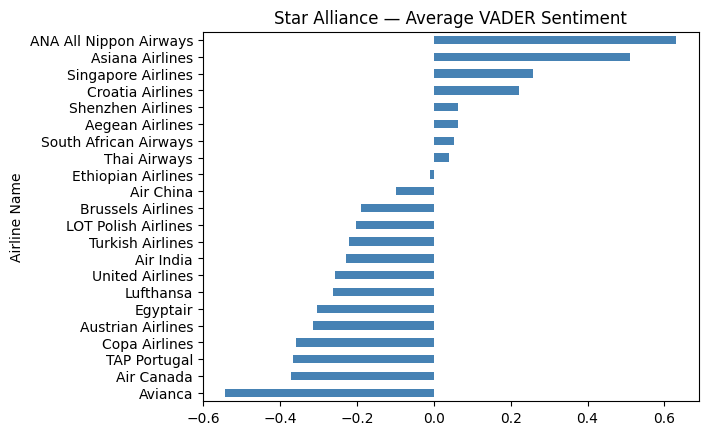

In [ ]:
star_alliance_members = [
    'Aegean Airlines','Air Canada','Air China','Air India',
    'ANA All Nippon Airways','Asiana Airlines','Austrian Airlines',
    'Avianca','Brussels Airlines','Copa Airlines','Croatia Airlines',
    'Egyptair','Ethiopian Airlines','Eva Air','LOT Polish Airlines',
    'Lufthansa','Scandinavian Airlines','Shenzhen Airlines',
    'Singapore Airlines','South African Airways',
    'Swiss International Air Lines','TAP Portugal',
    'Thai Airways','Turkish Airlines','United Airlines'
]

f_star = df['Airline Name'].isin(star_alliance_members)
df[f_star].groupby('Airline Name')['sentiment'].mean().sort_values().plot.barh(
    color='steelblue', title='Star Alliance — Average VADER Sentiment'
);

> What follow-up analysis would you do if you worked at Star Alliance?

---
## Part III: Topic Modeling

So far we've looked at *which words* appear (Part I) and *how positive or negative* a review is (Part II). But neither approach tells us *what* passengers are actually talking about when they're happy or unhappy.

**Topic modeling** is an unsupervised technique that scans a large collection of documents and automatically groups words that tend to occur together into "topics" — without you ever telling it what to look for. The most widely-used algorithm is **Latent Dirichlet Allocation (LDA)**: it assumes every review is a mix of a handful of topics, and every topic is a mix of words.

You don't need to understand the underlying math to use it — `scikit-learn` (already installed in Colab/Anaconda) does the heavy lifting. Our recipe:

1. Turn each review into a row of word counts (a "bag of words")
2. Fit an LDA model and ask for, say, 5 topics
3. Look at the top words per topic and give each one a human-readable label
4. Combine topics with the sentiment scores from Part II to see which topics make passengers happiest — and unhappiest

> 🧠 **Pause and Think:** Before running anything below — based on the wordcloud and reviews you've already seen, write down 4–5 topics you expect to find (e.g., "food", "delays", "seat comfort"...). We'll compare these to what the model finds.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# bag-of-words: turn each review into a row of word counts
# - stop_words='english' drops common words like 'the', 'a', 'and'
# - max_df=0.9  drops words that appear in >90% of reviews (too common to be useful)
# - min_df=10   drops words that appear in fewer than 10 reviews (too rare)
# - max_features=1000 keeps only the 1000 most frequent remaining words
vectorizer = CountVectorizer(stop_words='english', max_df=0.9, min_df=10, max_features=1000)
dtm = vectorizer.fit_transform(df['Review'])

dtm.shape

(23046, 1000)

> ✅ **Sanity check:** `dtm.shape` should be `(23046, 1000)` — one row per review, one column per word in our vocabulary. `dtm` is a *document-term matrix*: row $i$, column $j$ counts how often word $j$ appears in review $i$.

In [ ]:
dtm[0,0]

np.int64(0)

In [ ]:
# fit the topic model
# n_components = how many topics we want LDA to look for
n_topics = 5

lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, verbose=2)
lda.fit(dtm)

# this may take a minute or two - LDA is iterative (verbose will give us updates)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   15.6s finished


iteration: 1 of max_iter: 10


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   19.5s finished


iteration: 2 of max_iter: 10


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   19.9s finished


...

iteration: 9 of max_iter: 10


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    9.0s finished


iteration: 10 of max_iter: 10


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    5.7s finished


LatentDirichletAllocation(n_components=5, random_state=42, verbose=2)

If the above takes too long, you can load the data here

In [ ]:
import joblib
import urllib.request

VECTORIZER_URL = 'https://raw.githubusercontent.com/tamaravdd/iese-dsmba/7905b94315f07bd58d0577e2509c4c6b8744c5c3/resources/text/vectorizer.pkl'
LDA_URL        = 'https://raw.githubusercontent.com/tamaravdd/iese-dsmba/7905b94315f07bd58d0577e2509c4c6b8744c5c3/resources/text/lda_model.pkl'

vectorizer = joblib.load(urllib.request.urlopen(VECTORIZER_URL))
lda        = joblib.load(urllib.request.urlopen(LDA_URL))

# vectorizer was already fit on this dataset, so use transform (not fit_transform)
dtm = vectorizer.transform(df['Review'])

In [ ]:
# print the top 10 words for each topic
words = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_words = [words[i] for i in topic.argsort()[-10:][::-1]]
    print(f"Topic {topic_idx}: {', '.join(top_words)}")

Topic 0: check, luggage, bag, pay, airline, baggage, flight, airport, told, ticket
Topic 1: flight, hours, airport, delayed, time, airline, hour, day, delay, staff
Topic 2: flight, airline, customer, service, refund, cancelled, flights, ticket, booked, days
Topic 3: flight, good, service, food, crew, time, cabin, seats, class, flights
Topic 4: flight, plane, seat, seats, crew, boarding, time, passengers, minutes, cabin


> ✅ **Sanity check:** You should see 5 lists of 10 words each. Some lists will look quite "thematic" (e.g., crew, staff, friendly), others may look like a mix of unrelated words — LDA is not perfect, and that's normal. Do you think some topics could be dropped?

>✏️ **You try it**
>
> Look at the top words for each topic and give each one a short, descriptive name. Store your labels in a dictionary, e.g.:
> ```python
> topic_names = {
>     0: '...',
>     1: '...',
>     2: '...',
>     3: '...',
>     4: '...',
> }
> ```
> There's no single right answer — naming topics from their top words is a judgment call, just like coding qualitative data.

<details>
<summary>Click to reveal an example solution</summary>

Your topics may come out differently — LDA depends on the data and on `random_state` — but a typical 5-topic split for airline reviews looks something like:

```python
topic_names = {
    0: 'Check-in',
    1: 'Time',
    2: 'Cancellation and refunds',
    3: 'In-Flight experience',
    4: 'Boarding',
}
```

Look at *your* top words before copying this — relabel anything that doesn't fit.
</details>

In [ ]:
# topic_distributions: for each review, the probability it belongs to each topic
topic_distributions = lda.transform(dtm)

# assign each review to its single most likely (dominant) topic
df['topic'] = topic_distributions.argmax(axis=1)
df['topic_name'] = df['topic'].map(topic_names)

df['topic_name'].value_counts()

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    7.6s finished


,count
topic_name,
In-Flight experience,7983
Time,4408
Cancellation and refunds,4070
Boarding,3415
Check-in,3170


> ✅ **Sanity check:** The counts should add up to 23,046 (one topic per review). No category should be empty. If one is, try a different `random_state` or lower `n_topics`.

### Which topics are driving sentiment?

Recall the last plot of Part II — `f_star` grouped reviews by **airline** and plotted average VADER sentiment per airline. We can run the exact same idea, but group by **topic** instead:

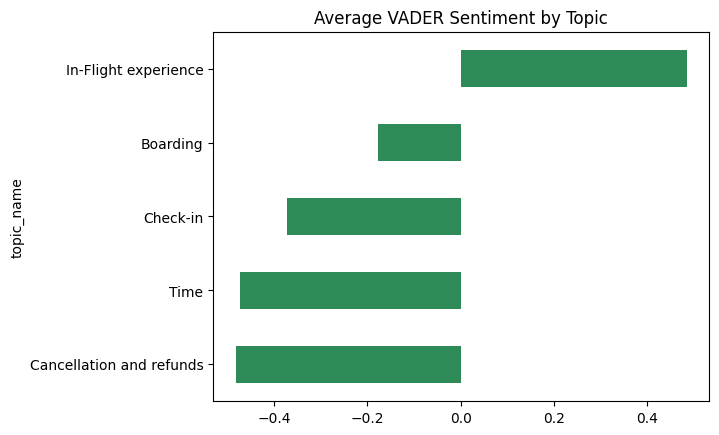

In [ ]:
df[f_star].groupby('topic_name')['sentiment'].mean().sort_values().plot.barh(
    color='seagreen', title='Average VADER Sentiment by Topic'
);

# looking at the star alliance airlines and grouping by most likely topic

> **Interpretation:** It seems like customers are generally very positive about their in-flight experience. However, the airport and customer service (related to delayed flights and waiting times) are what drives negative reviews.